# Genetic Algorithm Optimizer — Cineplex Scheduling

This notebook:

1. **Tunes the mutation rate** on the *small* dataset (`movies_small.csv`, `small_config.json`) for **weekend** demand, plots **best revenue vs mutation rate**, and picks a rate for the remaining runs.
2. **Runs the GA** on **small, medium, and large** instances (weekend) with that rate, records **best / average fitness vs generation**, and writes `schedule_*_ga.json` under `heuristic(GA)/`.
3. **Runs the exact ILP** on the same instances for timing and revenue baselines.
4. **Validates** outputs with `validator.py` (hall overlap + cleaning buffer, lobby cap, horizon / “1 AM” slot bound, `min_shows`, revenue consistency).
5. **Compares** wall time, RSS-style peak memory hints, scalability, feasibility, and **revenue vs speed** (GA vs ILP).


In [38]:
# Library installation (restart kernel if pip upgrades packages)
%pip install -q pandas numpy matplotlib ortools



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [39]:
from __future__ import annotations

import importlib.util
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

def _find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(6):
        if (p / "heuristic(GA)" / "ga_solve.py").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    return Path.cwd().resolve()

REPO_ROOT = _find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

_spec_ga = importlib.util.spec_from_file_location(
    "ga_solve",
    REPO_ROOT / "heuristic(GA)" / "ga_solve.py",
)
_ga = importlib.util.module_from_spec(_spec_ga)
assert _spec_ga.loader is not None
sys.modules["ga_solve"] = _ga
_spec_ga.loader.exec_module(_ga)
GAProblem = _ga.GAProblem
from validator import validate

# Load exact ILP solver (no package __init__ in exact_method/)
_spec = importlib.util.spec_from_file_location(
    "exact_scheduler",
    REPO_ROOT / "exact_method" / "exact_scheduler.py",
)
_exact = importlib.util.module_from_spec(_spec)
assert _spec.loader is not None
sys.modules["exact_scheduler"] = _exact
_spec.loader.exec_module(_exact)
solve_schedule_ilp = _exact.solve_schedule_ilp

DAY_TYPE = "weekend"

DATASETS = [
    ("small", REPO_ROOT / "common" / "movies_small.csv", REPO_ROOT / "common" / "small_config.json"),
    ("medium", REPO_ROOT / "common" / "movies_medium.csv", REPO_ROOT / "common" / "med_config.json"),
    ("large", REPO_ROOT / "common" / "movies_large.csv", REPO_ROOT / "common" / "large_config.json"),
]

GA_DIR = REPO_ROOT / "heuristic(GA)"
GA_DIR.mkdir(parents=True, exist_ok=True)

# Shared GA hyperparameters (mutation rate is tuned in the next section)
POPULATION_SIZE = 150
NUM_GENERATIONS = 500
TUNE_GENERATIONS = 250  # shorter runs for mutation sweep (keeps the notebook responsive)
TOURNAMENT_SIZE = 5
CROSSOVER_RATE = 0.85
ELITISM_COUNT = 2
TUNE_SEED = 42


## 1. Mutation-rate tuning (small + medium, weekend)

We sweep `mutation_rate` on both the small and medium instances with a fixed random seed and a reduced generation budget (`TUNE_GENERATIONS`). For each dataset, we pick the rate that maximises **best revenue** at the end of the run, then use the average of those two best rates as `OPTIMAL_MUTATION_RATE`.


Best mutation rate on small : 0.750 (revenue=3762.0885)
Best mutation rate on medium: 0.950 (revenue=15978.4481)
Chosen mutation rate (average of best rates): 0.850


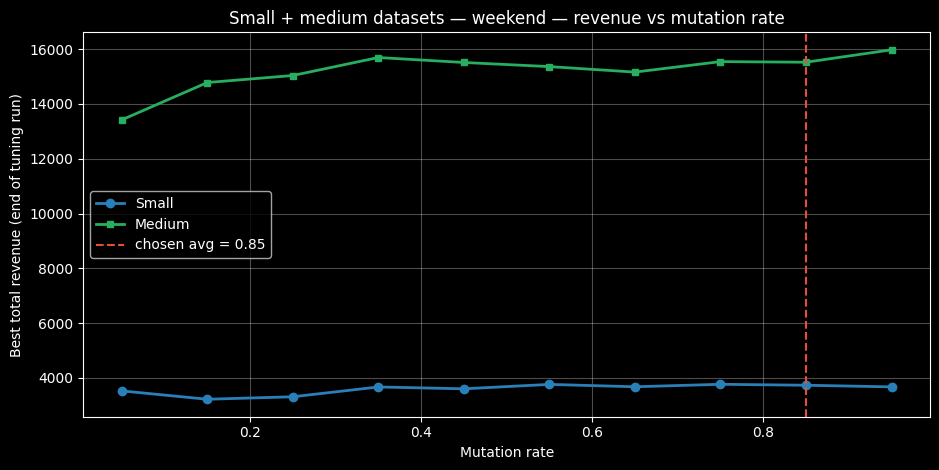

In [40]:
mutation_rates = np.linspace(0.05, 0.95, 10)
tune_revenues_by_dataset: dict[str, list[float]] = {}
best_rate_by_dataset: dict[str, float] = {}
best_revenue_by_dataset: dict[str, float] = {}

tune_targets = [
    ("small", DATASETS[0][1], DATASETS[0][2]),
    ("medium", DATASETS[1][1], DATASETS[1][2]),
]

for ds_name, csv_p, cfg_p in tune_targets:
    prob = GAProblem.from_files(csv_p, cfg_p, day_type=DAY_TYPE)
    ds_revenues: list[float] = []
    for mr in mutation_rates:
        res, _hist, _diag = prob.solve(
            pop_size=POPULATION_SIZE,
            generations=TUNE_GENERATIONS,
            mutation_rate=float(mr),
            crossover_rate=CROSSOVER_RATE,
            tournament_size=TOURNAMENT_SIZE,
            elitism_count=ELITISM_COUNT,
            seed=TUNE_SEED,
            verbose=False,
        )
        ds_revenues.append(float(res["metadata"]["total_revenue"]))

    tune_revenues_by_dataset[ds_name] = ds_revenues
    best_idx = int(np.argmax(ds_revenues))
    best_rate_by_dataset[ds_name] = float(mutation_rates[best_idx])
    best_revenue_by_dataset[ds_name] = ds_revenues[best_idx]

OPTIMAL_MUTATION_RATE = float(np.mean(list(best_rate_by_dataset.values())))
print(f"Best mutation rate on small : {best_rate_by_dataset['small']:.3f} (revenue={best_revenue_by_dataset['small']:.4f})")
print(f"Best mutation rate on medium: {best_rate_by_dataset['medium']:.3f} (revenue={best_revenue_by_dataset['medium']:.4f})")
print(f"Chosen mutation rate (average of best rates): {OPTIMAL_MUTATION_RATE:.3f}")

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(
    mutation_rates,
    tune_revenues_by_dataset["small"],
    "o-",
    color="#2980b9",
    linewidth=2,
    markersize=6,
    label="Small",
)
ax.plot(
    mutation_rates,
    tune_revenues_by_dataset["medium"],
    "s-",
    color="#27ae60",
    linewidth=2,
    markersize=5,
    label="Medium",
)
ax.axvline(
    OPTIMAL_MUTATION_RATE,
    color="#e74c3c",
    linestyle="--",
    label=f"chosen avg = {OPTIMAL_MUTATION_RATE:.2f}",
)
ax.set_xlabel("Mutation rate")
ax.set_ylabel("Best total revenue (end of tuning run)")
ax.set_title("Small + medium datasets — weekend — revenue vs mutation rate")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 2. GA on all datasets (weekend)

Full runs use `NUM_GENERATIONS` and `OPTIMAL_MUTATION_RATE`. We store convergence history and solver diagnostics (wall time, last generation with improvement, `tracemalloc` peak when available).


In [41]:
ga_results: dict[str, dict] = {}

for name, csv_p, cfg_p in DATASETS:
    print(f"\n=== GA {name} ({DAY_TYPE}) ===")
    prob = GAProblem.from_files(csv_p, cfg_p, day_type=DAY_TYPE)
    t0 = time.perf_counter()
    res, hist, diag = prob.solve(
        pop_size=POPULATION_SIZE,
        generations=NUM_GENERATIONS,
        mutation_rate=OPTIMAL_MUTATION_RATE,
        crossover_rate=CROSSOVER_RATE,
        tournament_size=TOURNAMENT_SIZE,
        elitism_count=ELITISM_COUNT,
        seed=TUNE_SEED,
        verbose=True,
        trace_memory=True,
    )
    diag["wall_instrumented_seconds"] = time.perf_counter() - t0
    out_path = GA_DIR / f"schedule_{name}_ga.json"
    out_path.write_text(json.dumps(res, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"Wrote {out_path}")
    ga_results[name] = {"result": res, "history": hist, "diagnostics": diag, "paths": (csv_p, cfg_p)}



=== GA small (weekend) ===
Gen    0  |  best fitness 2.378147e+03  |  revenue 2.378147e+03  |  violations 0  |  avg fitness -6.821814e+04
Gen   50  |  best fitness 3.727917e+03  |  revenue 3.727917e+03  |  violations 0  |  avg fitness 2.375440e+03
Gen  100  |  best fitness 3.727917e+03  |  revenue 3.727917e+03  |  violations 0  |  avg fitness -9.818283e+01
Gen  150  |  best fitness 3.727917e+03  |  revenue 3.727917e+03  |  violations 0  |  avg fitness 1.937597e+03
Gen  200  |  best fitness 3.727917e+03  |  revenue 3.727917e+03  |  violations 0  |  avg fitness -9.006123e+02
Gen  250  |  best fitness 3.727917e+03  |  revenue 3.727917e+03  |  violations 0  |  avg fitness -1.301628e+03
Gen  300  |  best fitness 3.727917e+03  |  revenue 3.727917e+03  |  violations 0  |  avg fitness -4.997235e+02
Gen  350  |  best fitness 3.727917e+03  |  revenue 3.727917e+03  |  violations 0  |  avg fitness 1.533046e+03
Gen  400  |  best fitness 3.727917e+03  |  revenue 3.727917e+03  |  violations 0  |  av

KeyboardInterrupt: 

## 3. Convergence: best and average fitness vs generation


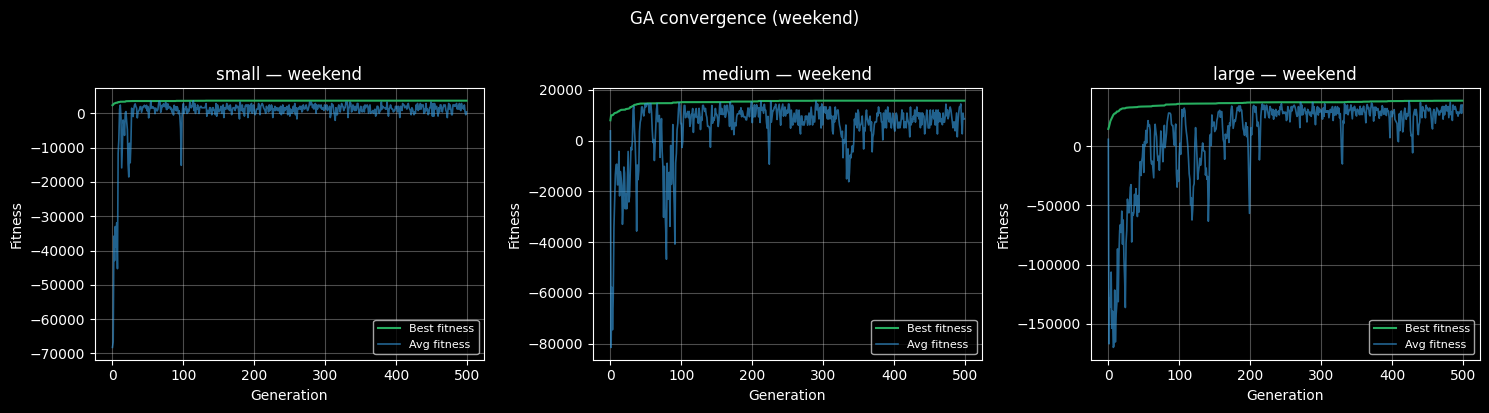

In [ ]:
fig, axes = plt.subplots(
    1, len(DATASETS), figsize=(5 * len(DATASETS), 4), sharex=False
)
for ax, (name, _csv, _cfg) in zip(axes, DATASETS):
    hist = ga_results[name]["history"]
    ax.plot(hist["gen"], hist["best_fit"], label="Best fitness", color="#27ae60", linewidth=1.5)
    ax.plot(hist["gen"], hist["avg_fit"], label="Avg fitness", color="#3498db", alpha=0.65, linewidth=1.2)
    ax.set_title(f"{name} — {DAY_TYPE}")
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fitness")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
plt.suptitle("GA convergence (weekend)", y=1.02)
plt.tight_layout()
plt.show()


## 4. Exact ILP baseline (weekend)

Same CSV/config and `DAY_TYPE` as the GA. **Peak memory** is reported as `ru_maxrss` (bytes on macOS, KB×1024 adjusted in `ga_solve` only for non-macOS; here we print raw `ru_maxrss` after the solve for a rough comparison).


In [ ]:
ilp_results: dict[str, dict] = {}

import resource

for name, csv_p, cfg_p in DATASETS:
    print(f"\n=== ILP {name} ({DAY_TYPE}) ===")
    ru0 = resource.getrusage(resource.RUSAGE_SELF)
    t0 = time.perf_counter()
    res = solve_schedule_ilp(
        movies_csv=csv_p,
        config_json=cfg_p,
        day_type=DAY_TYPE,
        time_limit_seconds=120,
    )
    wall = time.perf_counter() - t0
    ru1 = resource.getrusage(resource.RUSAGE_SELF)
    out_path = REPO_ROOT / "exact_method" / f"schedule_{name}_ilp.json"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_text(json.dumps(res, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"Wrote {out_path} | status={res['metadata']['solver_status']} | wall={wall:.3f}s")
    ilp_results[name] = {
        "result": res,
        "wall_seconds": wall,
        "ru_maxrss_after": ru1.ru_maxrss,
        "ru_maxrss_delta": ru1.ru_maxrss - ru0.ru_maxrss,
    }



=== ILP small (weekend) ===
Wrote /Users/yogeshganesh/Desktop/Experiments/MSc/Y1S2/IT5082 OM/Assignment/IT5082-Optimisation-Methods-Assignment/exact_method/schedule_small_ilp.json | status=OPTIMAL | wall=0.170s

=== ILP medium (weekend) ===
Wrote /Users/yogeshganesh/Desktop/Experiments/MSc/Y1S2/IT5082 OM/Assignment/IT5082-Optimisation-Methods-Assignment/exact_method/schedule_medium_ilp.json | status=OPTIMAL | wall=0.380s

=== ILP large (weekend) ===
Wrote /Users/yogeshganesh/Desktop/Experiments/MSc/Y1S2/IT5082 OM/Assignment/IT5082-Optimisation-Methods-Assignment/exact_method/schedule_large_ilp.json | status=OPTIMAL | wall=88.154s


## 4b. Schedule Gantt charts

Horizontal axis is **wall-clock time** derived from each hall config (`opening_time`, `slot_duration_minutes`, `num_slots`). Bars match `start_slot` / `end_slot` from the JSON. After midnight, tick labels use a **(+1)** suffix for the next calendar day.


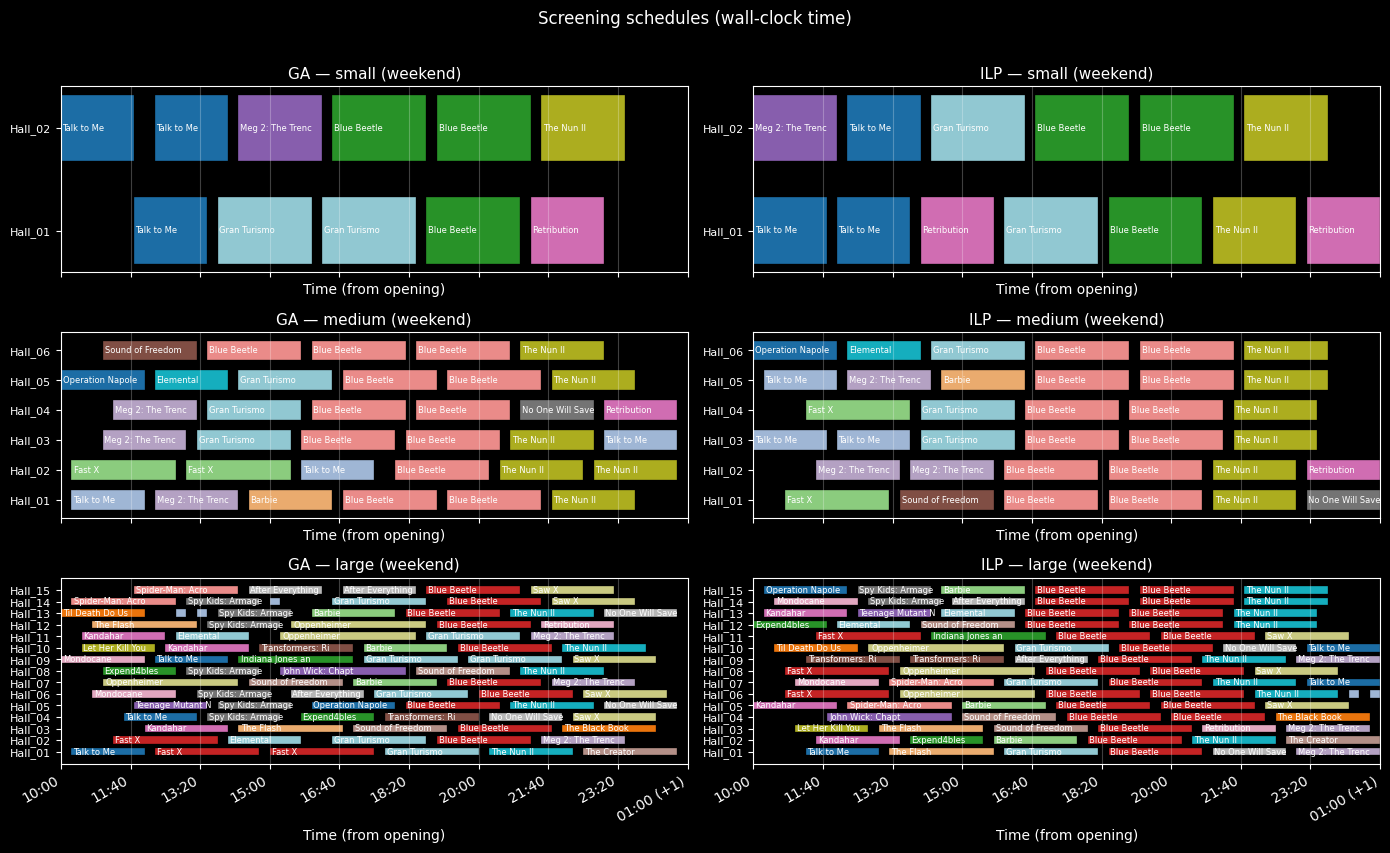

In [ ]:
def _opening_minutes_and_slot_duration(config: dict) -> tuple[int, int, int]:
    """Return (opening_minutes_from_midnight, slot_duration_min, num_slots)."""
    c = config["constraints"]
    slot_dur = int(c["slot_duration_minutes"])
    oh, om = (int(x) for x in str(c["opening_time"]).strip().split(":"))
    ch, cm = (int(x) for x in str(c["closing_time"]).strip().split(":"))
    opening = oh * 60 + om
    closing = ch * 60 + cm
    if bool(c.get("closing_time_is_next_calendar_day", True)) and closing <= opening:
        closing += 24 * 60
    num_slots = (closing - opening) // slot_dur
    return opening, slot_dur, num_slots


def plot_schedule_gantt(ax, result: dict, title: str, config: dict) -> None:
    """Barh Gantt: one row per hall; x = minutes after opening (ticks show HH:MM)."""
    schedule = result.get("schedule") or []
    meta = result.get("metadata") or {}
    opening_min, slot_dur, cfg_slots = _opening_minutes_and_slot_duration(config)
    num_slots = int(meta.get("num_slots", cfg_slots))
    span_min = num_slots * slot_dur

    def fmt_time_from_opening(x, _pos):
        total_min = int(round(opening_min + float(x)))
        h, m = divmod(total_min, 60)
        suffix = ""
        if h >= 24:
            suffix = " (+1)"
            h = h % 24
        return f"{h:02d}:{m:02d}{suffix}"

    if not schedule:
        ax.set_title(f"{title} (empty schedule)")
        return
    halls = sorted({r["hall_id"] for r in schedule})
    hall_to_y = {h: i for i, h in enumerate(halls)}
    movie_ids = sorted({str(r["movie_id"]) for r in schedule})
    n_mov = len(movie_ids)
    cmap = plt.colormaps["tab20"].resampled(max(n_mov, 1))
    colors = {m: cmap(i / max(n_mov - 1, 1)) for i, m in enumerate(movie_ids)}
    for r in schedule:
        y = hall_to_y[r["hall_id"]]
        t0 = int(r["start_slot"])
        t1 = int(r["end_slot"])
        n_slot = t1 - t0
        if n_slot <= 0:
            continue
        left = t0 * slot_dur
        width = n_slot * slot_dur
        ax.barh(
            y,
            width,
            left=left,
            height=0.65,
            color=colors[str(r["movie_id"])],
            edgecolor="black",
            linewidth=0.25,
            alpha=0.92,
        )
        if n_slot >= 5:
            label = str(r.get("movie_title", ""))[:16]
            ax.text(left + 0.02 * width, y, label, va="center", fontsize=6, clip_on=True)
    ax.set_yticks(range(len(halls)))
    ax.set_yticklabels(halls, fontsize=8)
    ax.set_xlim(0, span_min)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(fmt_time_from_opening))
    ax.set_xlabel("Time (from opening)")
    ax.set_title(title, fontsize=11)
    ax.grid(True, axis="x", alpha=0.25)
    for tick in ax.get_xticklabels():
        tick.set_rotation(30)
        tick.set_ha("right")


n_ds = len(DATASETS)
fig, axes = plt.subplots(n_ds, 2, figsize=(14, max(3.0, 2.8 * n_ds)), sharex="col")
if n_ds == 1:
    axes = np.array([axes])

for i, (name, _csv, cfg_p) in enumerate(DATASETS):
    _cfg_dict = json.loads(cfg_p.read_text(encoding="utf-8"))
    plot_schedule_gantt(
        axes[i, 0],
        ga_results[name]["result"],
        f"GA — {name} ({DAY_TYPE})",
        _cfg_dict,
    )
    plot_schedule_gantt(
        axes[i, 1],
        ilp_results[name]["result"],
        f"ILP — {name} ({DAY_TYPE})",
        _cfg_dict,
    )

plt.suptitle("Screening schedules (wall-clock time)", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()


## 5. Validation (`validator.py` logic)

Structural checks: **no hall overlap** with **cleaning buffer** (`end_slot + buffer` before the next `start_slot`), **lobby cap** on simultaneous starts, **slot horizon** (`end_slot <= num_slots`), **`min_shows`**, and **revenue** recomputed with `common.utils.calculate_screening_revenue`.


In [ ]:
for name, csv_p, cfg_p in DATASETS:
    ga_path = GA_DIR / f"schedule_{name}_ga.json"
    ilp_path = REPO_ROOT / "exact_method" / f"schedule_{name}_ilp.json"
    for label, p in [("GA", ga_path), ("ILP", ilp_path)]:
        ok, issues = validate(p, csv_p, cfg_p, day_type=DAY_TYPE)
        status = "OK" if ok else "FAILED"
        print(f"{label} {name}: {status}")
        if not ok:
            for line in issues[:12]:
                print(f"   - {line}")
            if len(issues) > 12:
                print(f"   ... ({len(issues) - 12} more)")


GA small: OK
ILP small: OK
GA medium: OK
ILP medium: OK
GA large: OK
ILP large: OK


## 6. Comparison: runtime scalability, memory hints, revenue vs speed

- **Runtime vs dataset size** (movie count): wall seconds for GA and ILP.
- **Trade-off scatter**: x = ILP wall time / GA wall time (how many times faster the GA finished), y = GA revenue as % of ILP revenue.


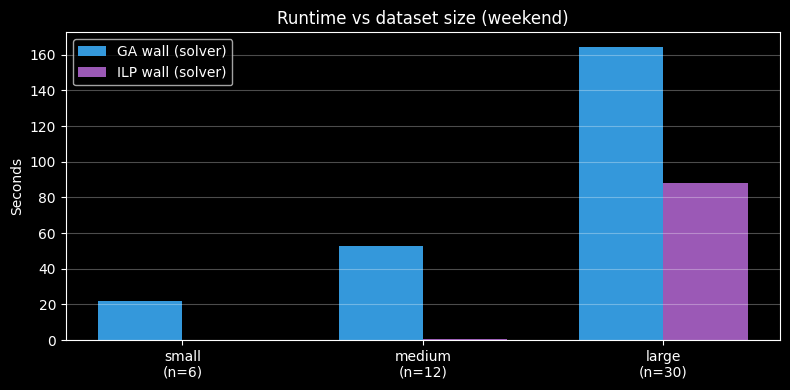

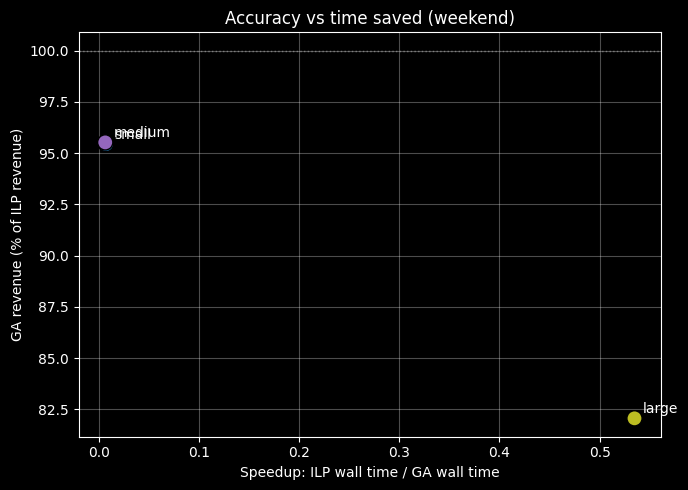


Dataset     n_mov     GA_s    ILP_s    spd   GA%ILP  GA conv   trc MB  GA rss MB  ILP rss MB
small           6   21.839    0.158   0.01   95.44%      137    10.19     772.19      772.19
medium         12   52.848    0.341   0.01   95.52%      286     0.90     772.19      772.19
large          30  164.346   87.894   0.53   82.06%      483     2.08     772.19      772.19

Notes:
- spd: ILP wall / GA wall (>1 ⇒ GA faster on this machine).
- GA conv: last generation with a best-fitness improvement.
- trc MB: tracemalloc peak (Python heap only).
- rss MB: ru_maxrss after solve (interpretation varies by OS; see cell above).


In [ ]:
import sys

movie_counts = []
ga_times = []
ilp_times = []
ga_mem_trace = []
ga_rss = []
ilp_rss = []
ga_conv_gen = []
ga_rev_pct = []

for name, csv_p, cfg_p in DATASETS:
    import pandas as pd
    n_mov = len(pd.read_csv(csv_p))
    movie_counts.append(n_mov)
    g = ga_results[name]
    i = ilp_results[name]
    ga_t = float(g["result"]["metadata"]["execution_time_seconds"])
    ilp_t = float(i["result"]["metadata"]["execution_time_seconds"])
    ga_times.append(ga_t)
    ilp_times.append(ilp_t)
    tm = g["diagnostics"].get("tracemalloc_peak_bytes")
    ga_mem_trace.append(tm / 1e6 if tm else float("nan"))
    ga_rss.append(g["diagnostics"].get("peak_rss_bytes", float("nan")))
    ilp_rss.append(i["ru_maxrss_after"])
    ga_conv_gen.append(g["diagnostics"]["last_improvement_generation"])
    gr = float(g["result"]["metadata"]["total_revenue"])
    ir = float(i["result"]["metadata"]["total_revenue"])
    ga_rev_pct.append(100.0 * gr / ir if ir > 0 else float("nan"))

x = np.arange(len(DATASETS))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width / 2, ga_times, width, label="GA wall (solver)", color="#3498db")
ax.bar(x + width / 2, ilp_times, width, label="ILP wall (solver)", color="#9b59b6")
ax.set_xticks(x)
ax.set_xticklabels([f"{d[0]}\n(n={c})" for d, c in zip(DATASETS, movie_counts)])
ax.set_ylabel("Seconds")
ax.set_title(f"Runtime vs dataset size ({DAY_TYPE})")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

speedup = [ilp_times[i] / ga_times[i] if ga_times[i] > 0 else float("nan") for i in range(len(DATASETS))]
fig, ax = plt.subplots(figsize=(7, 5))
_colors = plt.cm.tab10(np.linspace(0, 0.85, len(DATASETS)))
ax.scatter(speedup, ga_rev_pct, s=120, c=_colors, edgecolors="k", zorder=3)
for i, name in enumerate([d[0] for d in DATASETS]):
    ax.annotate(name, (speedup[i], ga_rev_pct[i]), textcoords="offset points", xytext=(6, 4))
ax.axhline(100.0, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Speedup: ILP wall time / GA wall time")
ax.set_ylabel("GA revenue (% of ILP revenue)")
ax.set_title("Accuracy vs time saved (weekend)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table (ru_maxrss: bytes on macOS, kilobytes on many Linux distros)
def _rss_to_mb(ru: float) -> float:
    v = float(ru)
    if sys.platform == "darwin":
        return v / 1e6
    return v * 1024.0 / 1e6

print(
    f"\n{'Dataset':<10} {'n_mov':>6} {'GA_s':>8} {'ILP_s':>8} {'spd':>6} {'GA%ILP':>8} "
    f"{'GA conv':>8} {'trc MB':>8} {'GA rss MB':>10} {'ILP rss MB':>11}"
)
for i, name in enumerate([d[0] for d in DATASETS]):
    print(
        f"{name:<10} {movie_counts[i]:>6} {ga_times[i]:>8.3f} {ilp_times[i]:>8.3f} {speedup[i]:>6.2f} "
        f"{ga_rev_pct[i]:>7.2f}% {ga_conv_gen[i]:>8} {ga_mem_trace[i]:>8.2f} "
        f"{_rss_to_mb(ga_rss[i]):>10.2f} {_rss_to_mb(ilp_rss[i]):>11.2f}"
    )
print("\nNotes:")
print("- spd: ILP wall / GA wall (>1 ⇒ GA faster on this machine).")
print("- GA conv: last generation with a best-fitness improvement.")
print("- trc MB: tracemalloc peak (Python heap only).")
print("- rss MB: ru_maxrss after solve (interpretation varies by OS; see cell above).")


## 7. Optional: inspect one schedule (GA)

Uncomment to print a compact table for the large instance.


In [ ]:
# name = "large"
# res = ga_results[name]["result"]
# print(f"\n{'Hall':<10} {'Movie':<22} {'Start':<8} {'End':<8} {'Revenue':>12}")
# for row in res["schedule"]:
#     print(
#         f"{row['hall_id']:<10} {str(row['movie_title'])[:20]:<22} "
#         f"{row['start_time']:<8} {row['end_time']:<8} {row['expected_revenue']:>12.2f}"
#     )
pass
